# Permutation Feature Importance

In [5]:
import xarray as xr
from pkg.pfi.run_pfi import run_pfi, evaluate_pfi_folder

In [6]:
input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
original_prediction_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc"

input = xr.open_dataset(input_path)
input_target_last = input.isel(time=-1)

In [7]:
surface_variables = [
    "2m_temperature",
    ("10m_u_component_of_wind",
    "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
]

atmospheric_variables = [
    "temperature",
    ("u_component_of_wind",
    "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

lower_troposphere = (850, 925, 1000)
mid_troposphere = (500, 600, 700)
upper_troposphere = (250, 300, 400)
stratospheric_levels  = (50, 100, 150, 200)

pressure_level_groups = [
    lower_troposphere,
    mid_troposphere,
    upper_troposphere,
    stratospheric_levels,
]

pressure_levels = [
    1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50
]

regions = [
    "atlantic_jet_stream",
    "storm_core",
    "dynamic_uljs",
    "storm_region",
    "high_pressure_south",
    "low_pressure_north",
    "north_germany"
]

In [ ]:
run_pfi(
    ds_input=input,
    features=atmospheric_variables,
    folder= "variables",
    repetitions=5
)


In [ ]:
run_pfi(
    ds_input=input,
    features=surface_variables,
    folder= "variables",
    repetitions=5
)

In [11]:
summary_df = evaluate_pfi_folder(
    reference=original_prediction_path,
    target=input_target_last,
    folder="../data/pfi/variables"
)

print(summary_df)


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:192: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference = xr.open_dataset(reference)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(file)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(file)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: Fut

                                           feature  mean_rmse  std_rmse  n  \
0  10m_u_component_of_wind_10m_v_component_of_wind   6.176160  1.114276  5   
1                                   2m_temperature   2.598696  0.686802  5   
2                                     geopotential   5.237984  0.422925  5   
3                          mean_sea_level_pressure   4.711496  0.559861  5   
4                                specific_humidity   2.476511  0.333978  5   
5                                      temperature   3.161531  0.742418  5   
6                          total_precipitation_6hr   1.998543  0.014570  5   
7          u_component_of_wind_v_component_of_wind   8.654118  0.361429  5   
8                                vertical_velocity   1.869258  0.088347  5   

   sem_rmse  delta_rmse  baseline_rmse  
0  0.498319    4.145935       2.030225  
1  0.307147    0.568471       2.030225  
2  0.189138    3.207759       2.030225  
3  0.250378    2.681271       2.030225  
4  0.149359   

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(file)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(file)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  pred = xr.open_dataset(file)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/pfi/run_pfi.py:213: FutureWarning

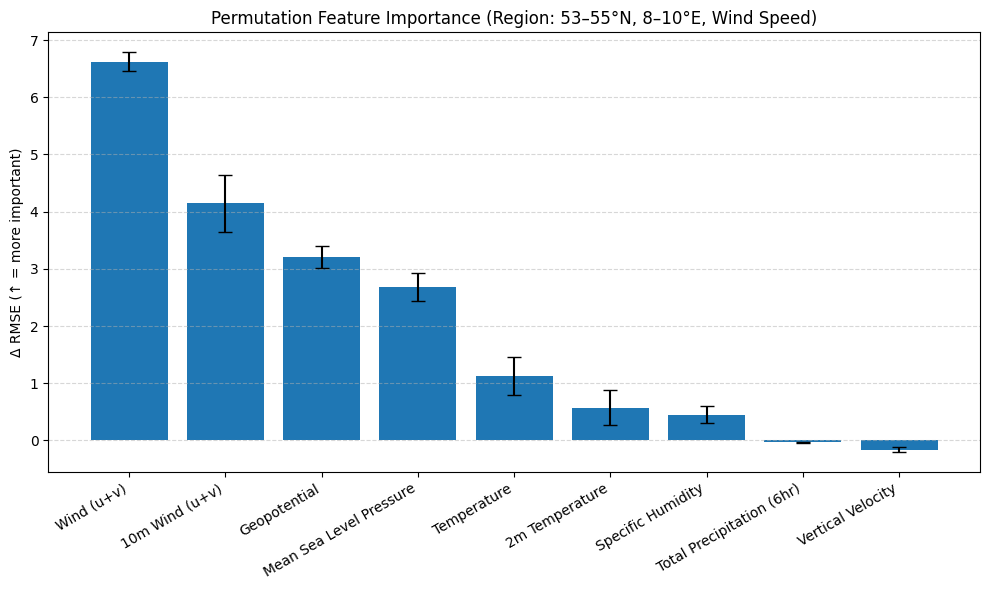

In [18]:
import matplotlib.pyplot as plt

# Sort by importance (delta_rmse)
plot_df = summary_df.sort_values("delta_rmse", ascending=False)

rename_map = {
    "geopotential": "Geopotential",
    "specific_humidity": "Specific Humidity",
    "temperature": "Temperature",
    "u_component_of_wind_v_component_of_wind": "Wind (u+v)",
    "vertical_velocity": "Vertical Velocity",
    "2m_temperature": "2m Temperature",
    "10m_u_component_of_wind_10m_v_component_of_wind": "10m Wind (u+v)",
    "total_precipitation_6hr": "Total Precipitation (6hr)",
    "mean_sea_level_pressure": "Mean Sea Level Pressure",
}

plot_df["pretty_feature"] = plot_df["feature"].replace(rename_map)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(
    plot_df["pretty_feature"],
    plot_df["delta_rmse"],
    yerr=plot_df["sem_rmse"],
    capsize=5
)


plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ RMSE (↑ = more important)")
plt.title("Permutation Feature Importance (Region: 53–55°N, 8–10°E, Wind Speed)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
